In [1]:
# Cell 0 — Setup
!pip -q install seaborn

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set(style="whitegrid")
np.set_printoptions(suppress=True, precision=3)
pd.set_option("display.max_columns", 0)

print("✅ Ready — NumPy/Pandas/Matplotlib/Seaborn loaded.")


✅ Ready — NumPy/Pandas/Matplotlib/Seaborn loaded.


In [2]:
# Cell 1 — Upload/load CSV (Colab-style)
from google.colab import files

# Ask for local upload (you can pick 'global_power_plant_database.csv')
print("📤 Please upload the CSV (e.g., global_power_plant_database.csv)")
uploaded = files.upload()

# Resolve filename and read robustly
filename = list(uploaded.keys())[0]
print("➡️ Using file:", filename)

# Try UTF-8 first, then fallbacks
for enc in (None, "utf-8", "latin-1", "cp1252"):
    try:
        df = pd.read_csv(filename, encoding=enc) if enc else pd.read_csv(filename)
        break
    except Exception as e:
        last_err = e
else:
    raise last_err

print("✅ Loaded shape:", df.shape)
df.head()


📤 Please upload the CSV (e.g., global_power_plant_database.csv)


Saving global_power_plant_database.csv to global_power_plant_database.csv
➡️ Using file: global_power_plant_database.csv
✅ Loaded shape: (34936, 36)


/tmp/ipython-input-1068322092.py:15: DtypeWarning: Columns (10) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(filename, encoding=enc) if enc else pd.read_csv(filename)


,country,country_long,name,gppd_idnr,capacity_mw,latitude,longitude,primary_fuel,other_fuel1,other_fuel2,other_fuel3,commissioning_year,owner,source,url,geolocation_source,wepp_id,year_of_capacity_data,generation_gwh_2013,generation_gwh_2014,generation_gwh_2015,generation_gwh_2016,generation_gwh_2017,generation_gwh_2018,generation_gwh_2019,generation_data_source,estimated_generation_gwh_2013,estimated_generation_gwh_2014,estimated_generation_gwh_2015,estimated_generation_gwh_2016,estimated_generation_gwh_2017,estimated_generation_note_2013,estimated_generation_note_2014,estimated_generation_note_2015,estimated_generation_note_2016,estimated_generation_note_2017
0,AFG,Afghanistan,Kajaki Hydroelectric Power Plant Afghanistan,GEODB0040538,33.0,32.322,65.1190,Hydro,NaN,NaN,NaN,NaN,NaN,GEODB,http://globalenergyobservatory.org,GEODB,1009793,2017.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,123.77,162.90,97.39,137.76,119.50,HYDRO-V1,HYDRO-V1,HYDRO-V1,HYDRO-V1,HYDRO-V1
1,AFG,Afghanistan,Kandahar DOG,WKS0070144,10.0,31.670,65.7950,Solar,NaN,NaN,NaN,NaN,NaN,Wiki-Solar,https://www.wiki-solar.org,Wiki-Solar,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.43,17.48,18.25,17.70,18.29,SOLAR-V1-NO-AGE,SOLAR-V1-NO-AGE,SOLAR-V1-NO-AGE,SOLAR-V1-NO-AGE,SOLAR-V1-NO-AGE
2,AFG,Afghanistan,Kandahar JOL,WKS0071196,10.0,31.623,65.7920,Solar,NaN,NaN,NaN,NaN,NaN,Wiki-Solar,https://www.wiki-solar.org,Wiki-Solar,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.64,17.58,19.10,17.62,18.72,SOLAR-V1-NO-AGE,SOLAR-V1-NO-AGE,SOLAR-V1-NO-AGE,SOLAR-V1-NO-AGE,SOLAR-V1-NO-AGE
3,AFG,Afghanistan,Mahipar Hydroelectric Power Plant Afghanistan,GEODB0040541,66.0,34.556,69.4787,Hydro,NaN,NaN,NaN,NaN,NaN,GEODB,http://globalenergyobservatory.org,GEODB,1009795,2017.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,225.06,203.55,146.90,230.18,174.91,HYDRO-V1,HYDRO-V1,HYDRO-V1,HYDRO-V1,HYDRO-V1
4,AFG,Afghanistan,Naghlu Dam Hydroelectric Power Plant Afghanistan,GEODB0040534,100.0,34.641,69.7170,Hydro,NaN,NaN,NaN,NaN,NaN,GEODB,http://globalenergyobservatory.org,GEODB,1009797,2017.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,406.16,357.22,270.99,395.38,350.80,HYDRO-V1,HYDRO-V1,HYDRO-V1,HYDRO-V1,HYDRO-V1


In [3]:
# Cell 2 — Inspect schema & keep essential columns
print("Columns:", list(df.columns))
essential = [
    "country","country_long","name","gppd_idnr","capacity_mw",
    "primary_fuel","other_fuel1","other_fuel2","other_fuel3",
    "commissioning_year","latitude","longitude"
]
present = [c for c in essential if c in df.columns]
print("Keeping:", present)

gppd = df[present].copy()

# Basic types & cleaning
numeric_cols = [c for c in ["capacity_mw","commissioning_year","latitude","longitude"] if c in gppd.columns]
for c in numeric_cols:
    gppd[c] = pd.to_numeric(gppd[c], errors="coerce")

# Drop rows without critical fields
gppd = gppd.dropna(subset=["capacity_mw","primary_fuel"])
print("✅ Cleaned shape:", gppd.shape)
gppd.head()


Columns: ['country', 'country_long', 'name', 'gppd_idnr', 'capacity_mw', 'latitude', 'longitude', 'primary_fuel', 'other_fuel1', 'other_fuel2', 'other_fuel3', 'commissioning_year', 'owner', 'source', 'url', 'geolocation_source', 'wepp_id', 'year_of_capacity_data', 'generation_gwh_2013', 'generation_gwh_2014', 'generation_gwh_2015', 'generation_gwh_2016', 'generation_gwh_2017', 'generation_gwh_2018', 'generation_gwh_2019', 'generation_data_source', 'estimated_generation_gwh_2013', 'estimated_generation_gwh_2014', 'estimated_generation_gwh_2015', 'estimated_generation_gwh_2016', 'estimated_generation_gwh_2017', 'estimated_generation_note_2013', 'estimated_generation_note_2014', 'estimated_generation_note_2015', 'estimated_generation_note_2016', 'estimated_generation_note_2017']
Keeping: ['country', 'country_long', 'name', 'gppd_idnr', 'capacity_mw', 'primary_fuel', 'other_fuel1', 'other_fuel2', 'other_fuel3', 'commissioning_year', 'latitude', 'longitude']
✅ Cleaned shape: (34936, 12)


,country,country_long,name,gppd_idnr,capacity_mw,primary_fuel,other_fuel1,other_fuel2,other_fuel3,commissioning_year,latitude,longitude
0,AFG,Afghanistan,Kajaki Hydroelectric Power Plant Afghanistan,GEODB0040538,33.0,Hydro,NaN,NaN,NaN,NaN,32.322,65.1190
1,AFG,Afghanistan,Kandahar DOG,WKS0070144,10.0,Solar,NaN,NaN,NaN,NaN,31.670,65.7950
2,AFG,Afghanistan,Kandahar JOL,WKS0071196,10.0,Solar,NaN,NaN,NaN,NaN,31.623,65.7920
3,AFG,Afghanistan,Mahipar Hydroelectric Power Plant Afghanistan,GEODB0040541,66.0,Hydro,NaN,NaN,NaN,NaN,34.556,69.4787
4,AFG,Afghanistan,Naghlu Dam Hydroelectric Power Plant Afghanistan,GEODB0040534,100.0,Hydro,NaN,NaN,NaN,NaN,34.641,69.7170


In [4]:
# Cell 3 — Missing & summary
print("Missing per column:")
display(gppd.isna().sum())

print("\nNumerical summary:")
display(gppd[["capacity_mw","commissioning_year","latitude","longitude"]].describe())


Missing per column:


,0
country,0
country_long,0
name,0
gppd_idnr,0
capacity_mw,0
primary_fuel,0
other_fuel1,32992
other_fuel2,34660
other_fuel3,34844
commissioning_year,17489



Numerical summary:


,capacity_mw,commissioning_year,latitude,longitude
count,34936.000000,17447.000000,34936.000000,34936.000000
mean,163.355148,1997.414823,32.816637,-6.972803
std,489.636072,23.397835,22.638603,78.405850
min,1.000000,1896.000000,-77.847000,-179.977700
25%,4.900000,1988.000000,29.256475,-77.641550
50%,16.745000,2007.000000,39.727750,-2.127100
75%,75.344250,2014.000000,46.263125,49.502675
max,22500.000000,2020.000000,71.292000,179.388700


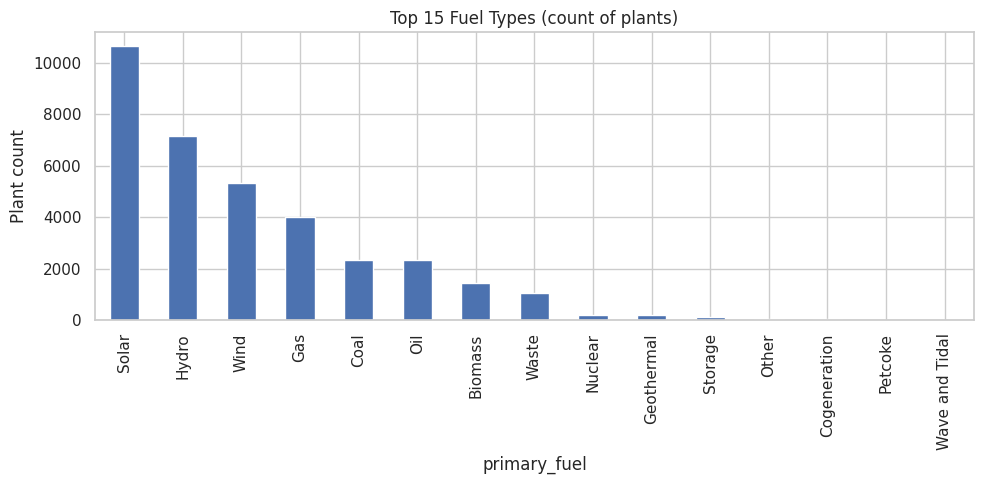

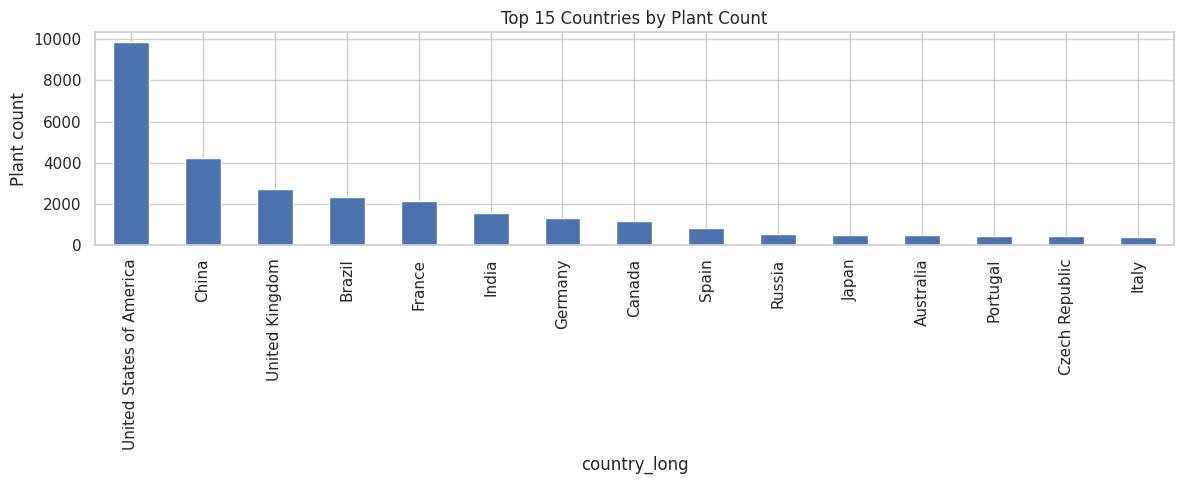

In [5]:
# Cell 4 — Counts/plots
plt.figure(figsize=(10,5))
gppd["primary_fuel"].value_counts().head(15).plot(kind="bar")
plt.title("Top 15 Fuel Types (count of plants)")
plt.ylabel("Plant count")
plt.tight_layout()
plt.show()

plt.figure(figsize=(12,5))
gppd["country_long"].value_counts().head(15).plot(kind="bar")
plt.title("Top 15 Countries by Plant Count")
plt.ylabel("Plant count")
plt.tight_layout()
plt.show()


,count,mean,median,std,sum
primary_fuel,,,,,
Coal,2330,843.58,600.00,888.19,1965541.00
Gas,3998,373.45,147.50,560.93,1493050.60
Hydro,7156,147.17,20.00,549.81,1053159.62
Nuclear,195,2091.86,1888.00,1303.51,407911.76
Wind,5344,49.22,27.00,106.14,263053.73
Oil,2320,112.88,9.00,392.01,261878.71
Solar,10665,17.66,5.80,41.94,188312.32
Biomass,1430,23.97,9.45,39.46,34281.30
Waste,1068,13.81,4.80,20.58,14748.71


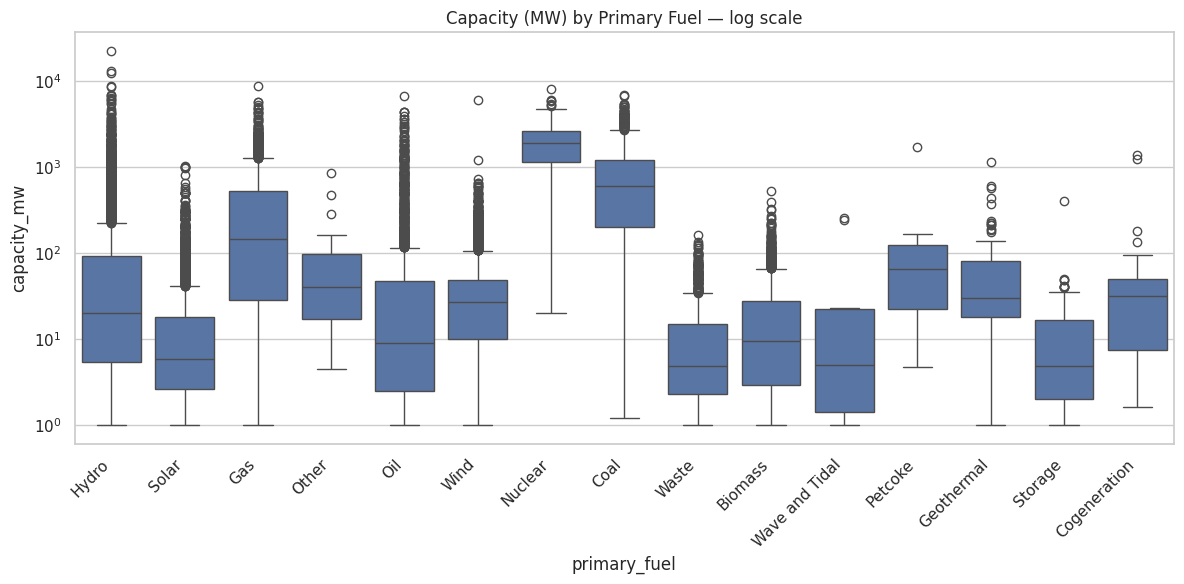

In [6]:
# Cell 5 — Capacity by fuel
cap_stats = (gppd
             .groupby("primary_fuel")["capacity_mw"]
             .agg(["count","mean","median","std","sum"])
             .sort_values("sum", ascending=False))
display(cap_stats.head(12).round(2))

plt.figure(figsize=(12,6))
sns.boxplot(data=gppd, x="primary_fuel", y="capacity_mw")
plt.xticks(rotation=45, ha="right")
plt.yscale("log")  # capacity is heavy-tailed
plt.title("Capacity (MW) by Primary Fuel — log scale")
plt.tight_layout()
plt.show()


In [7]:
# Cell 6 — Welch t-test: mean capacity differs between two fuels?
# Pick two common fuels present in the dataset:
fuels = (gppd["primary_fuel"].value_counts().index[:2].tolist())
fuel_a, fuel_b = fuels[0], fuels[1]
a = gppd.loc[gppd["primary_fuel"]==fuel_a, "capacity_mw"].dropna().values
b = gppd.loc[gppd["primary_fuel"]==fuel_b, "capacity_mw"].dropna().values

# Welch t-stat (NumPy only)
mean_a, mean_b = a.mean(), b.mean()
var_a, var_b = a.var(ddof=1), b.var(ddof=1)
na, nb = len(a), len(b)
t_num = mean_a - mean_b
t_den = np.sqrt(var_a/na + var_b/nb)
t_stat = t_num / t_den

print(f"Comparing mean capacity: {fuel_a} vs {fuel_b}")
print(f"mean_a={mean_a:.2f}  mean_b={mean_b:.2f}")
print(f"Welch t ≈ {t_stat:.3f}  (reference |t|>~1.96 for ~5% two-sided as a rough guide)")


Comparing mean capacity: Solar vs Hydro
mean_a=17.66  mean_b=147.17
Welch t ≈ -19.888  (reference |t|>~1.96 for ~5% two-sided as a rough guide)


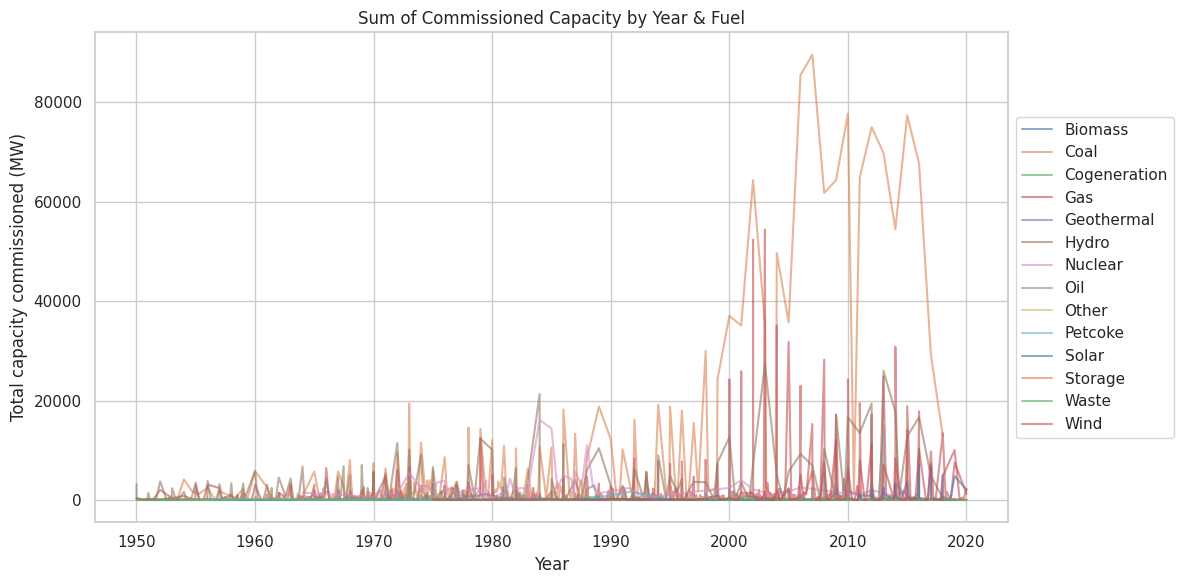

In [8]:
# Cell 7 — Commissioning year trends
ts = gppd.dropna(subset=["commissioning_year"]).copy()
# filter to reasonable years
ts = ts[(ts["commissioning_year"]>=1950) & (ts["commissioning_year"]<=2025)]

annual = (ts.groupby(["commissioning_year","primary_fuel"])["capacity_mw"]
            .sum()
            .reset_index())

plt.figure(figsize=(12,6))
for f, sub in annual.groupby("primary_fuel"):
    plt.plot(sub["commissioning_year"], sub["capacity_mw"], label=f, alpha=0.6)
plt.title("Sum of Commissioned Capacity by Year & Fuel")
plt.xlabel("Year")
plt.ylabel("Total capacity commissioned (MW)")
plt.legend(loc="center left", bbox_to_anchor=(1,0.5))
plt.tight_layout()
plt.show()


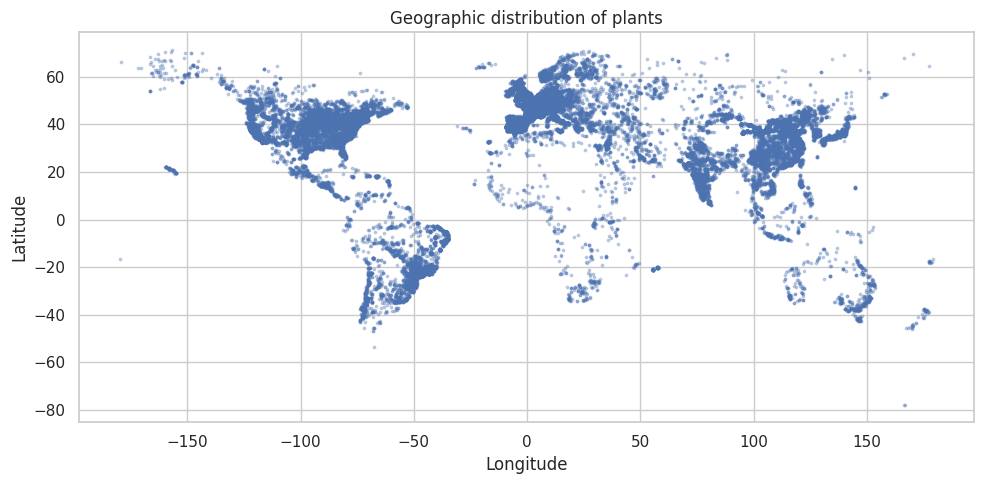

In [9]:
# Cell 8 — Geo scatter (quick look)
geo = gppd.dropna(subset=["latitude","longitude"]).copy()
plt.figure(figsize=(10,5))
plt.scatter(geo["longitude"], geo["latitude"], s=3, alpha=0.3)
plt.xlabel("Longitude"); plt.ylabel("Latitude")
plt.title("Geographic distribution of plants")
plt.tight_layout(); plt.show()


In [10]:
# Cell 9 — Matrix operations: eigen decomposition on standardized features
# Features: capacity, latitude, longitude (drop NaNs and scale)
mfeat = geo[["capacity_mw","latitude","longitude"]].dropna().to_numpy()
mmean = mfeat.mean(axis=0)
mstd  = mfeat.std(axis=0, ddof=1)
Z = (mfeat - mmean) / mstd  # standardize

# Covariance matrix (3x3) and eigendecomposition
Sigma = (Z.T @ Z) / (Z.shape[0] - 1)
eigvals, eigvecs = np.linalg.eig(Sigma)

print("Covariance matrix:\n", Sigma)
print("\nEigenvalues (variance explained by each component):\n", eigvals)
print("\nEigenvectors (principal directions as columns):\n", eigvecs)

# Variance explained ratio
ratio = eigvals / eigvals.sum()
print("\nVariance explained ratio:", np.round(ratio, 3))


Covariance matrix:
 [[ 1.    -0.013  0.152]
 [-0.013  1.    -0.068]
 [ 0.152 -0.068  1.   ]]

Eigenvalues (variance explained by each component):
 [1.171 0.838 0.99 ]

Eigenvectors (principal directions as columns):
 [[-0.64   0.651  0.408]
 [ 0.327 -0.25   0.912]
 [-0.696 -0.716  0.053]]

Variance explained ratio: [0.39  0.279 0.33 ]


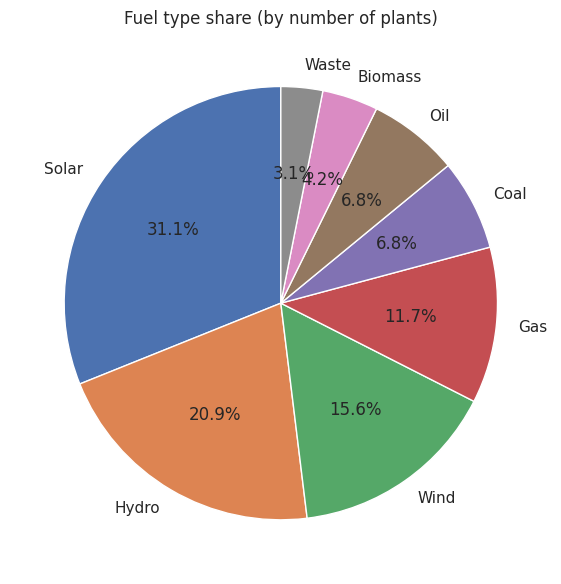

In [11]:
# Cell 10 — Fuel share pie (top fuels)
top_fuels = gppd["primary_fuel"].value_counts().head(8)
plt.figure(figsize=(6,6))
plt.pie(top_fuels.values, labels=top_fuels.index, autopct="%1.1f%%", startangle=90)
plt.title("Fuel type share (by number of plants)")
plt.tight_layout(); plt.show()


In [12]:
# Cell 11 — Short report
print("=== Report Summary ===")
print(f"Rows: {len(gppd):,} | Countries: {gppd['country_long'].nunique()} | Fuels: {gppd['primary_fuel'].nunique()}")
print("- Capacity by fuel (top 5 by total MW):")
cap_sum = (gppd.groupby('primary_fuel')['capacity_mw'].sum().sort_values(ascending=False).head(5))
print(cap_sum.to_string())

print("\nMatrix insight:")
print("We formed a 3×3 covariance matrix of standardized [capacity, lat, lon] and took eigenvectors.")
print("Eigenvectors ≈ principal axes; eigenvalues ≈ variance captured per axis (PCA intuition).")


=== Report Summary ===
Rows: 34,936 | Countries: 167 | Fuels: 15
- Capacity by fuel (top 5 by total MW):
primary_fuel
Coal       1.965541e+06
Gas        1.493051e+06
Hydro      1.053160e+06
Nuclear    4.079118e+05
Wind       2.630537e+05

Matrix insight:
We formed a 3×3 covariance matrix of standardized [capacity, lat, lon] and took eigenvectors.
Eigenvectors ≈ principal axes; eigenvalues ≈ variance captured per axis (PCA intuition).
